In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import math

In [3]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html#sklearn.ensemble.GradientBoostingClassifier.fit
# https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
df = pd.read_parquet('../data/features_elasticc_pseudo_obs.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354372 entries, 0 to 2354371
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   mag_peak      float64
 1   first_detect  float64
 2   time_peak     float64
 3   color         float64
 4   rate_dec_1    float64
 5   rate_dec_3    float64
 6   rate_inc      float64
 7   dt            float64
 8   type          object 
dtypes: float64(8), object(1)
memory usage: 161.7+ MB


In [5]:
df.fillna(0, inplace=True)
df.head()

,mag_peak,first_detect,time_peak,color,rate_dec_1,rate_dec_3,rate_inc,dt,type
0,21.967399,60275.1374,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
1,21.594604,60278.0322,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
2,21.594604,60278.0322,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
3,22.610292,60275.1465,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
4,22.940764,60276.2055,0.0,0.0,0.0,0.0,0.0,0.0,elasticc


In [6]:
df.tail()

,mag_peak,first_detect,time_peak,color,rate_dec_1,rate_dec_3,rate_inc,dt,type
2354367,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,pseudo-obs
2354368,21.390305,63546.349055,63546.362341,0.179629,0.000000,0.00000,0.000000,0.000000,pseudo-obs
2354369,20.757785,60998.218882,61139.021560,0.000000,0.000000,0.00000,-0.010760,72.024256,pseudo-obs
2354370,21.697711,61751.343813,61835.166034,0.316336,0.000072,0.00183,-0.004842,39.441263,pseudo-obs
2354371,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,pseudo-obs


In [7]:
df[100:200]

,mag_peak,first_detect,time_peak,color,rate_dec_1,rate_dec_3,rate_inc,dt,type
100,22.867283,60282.2473,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
101,20.807114,60277.3129,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
102,20.351623,60277.2748,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
103,22.702095,60278.2259,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
104,21.979386,60278.3166,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
...,...,...,...,...,...,...,...,...,...
195,23.475664,60314.0620,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
196,23.848204,60320.1058,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
197,23.031542,60276.3330,0.0,0.0,0.0,0.0,0.0,0.0,elasticc
198,22.082511,60275.1817,0.0,0.0,0.0,0.0,0.0,0.0,elasticc


In [8]:
# Create a sub dataframe with just elasticc data
el_df = df[df['type']=='elasticc']
el_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2112694 entries, 0 to 2112693
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   mag_peak      float64
 1   first_detect  float64
 2   time_peak     float64
 3   color         float64
 4   rate_dec_1    float64
 5   rate_dec_3    float64
 6   rate_inc      float64
 7   dt            float64
 8   type          object 
dtypes: float64(8), object(1)
memory usage: 161.2+ MB


In [9]:
ps_df = df[df['type']=='pseudo-obs']
ps_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 241678 entries, 2112694 to 2354371
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mag_peak      241678 non-null  float64
 1   first_detect  241678 non-null  float64
 2   time_peak     241678 non-null  float64
 3   color         241678 non-null  float64
 4   rate_dec_1    241678 non-null  float64
 5   rate_dec_3    241678 non-null  float64
 6   rate_inc      241678 non-null  float64
 7   dt            241678 non-null  float64
 8   type          241678 non-null  object 
dtypes: float64(8), object(1)
memory usage: 18.4+ MB


In [10]:
el_df_train = el_df[:100000].drop(columns=['type'])
el_df_test = el_df[100000:].drop(columns=['type'])
el_df_train.info()
el_y_train = el_df[:100000]['type']
el_y_test = el_df[100000:]['type']
el_y_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mag_peak      100000 non-null  float64
 1   first_detect  100000 non-null  float64
 2   time_peak     100000 non-null  float64
 3   color         100000 non-null  float64
 4   rate_dec_1    100000 non-null  float64
 5   rate_dec_3    100000 non-null  float64
 6   rate_inc      100000 non-null  float64
 7   dt            100000 non-null  float64
dtypes: float64(8)
memory usage: 6.9 MB
<class 'pandas.core.series.Series'>
Int64Index: 100000 entries, 0 to 99999
Series name: type
Non-Null Count   Dtype 
--------------   ----- 
100000 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [11]:
ps_df_train = ps_df[:100000].drop(columns=['type'])
ps_df_test = ps_df[100000:].drop(columns=['type'])
ps_df_train.info()
ps_y_train = ps_df[:100000]['type']
ps_y_test = ps_df[100000:]['type']
ps_y_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 2112694 to 2212693
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mag_peak      100000 non-null  float64
 1   first_detect  100000 non-null  float64
 2   time_peak     100000 non-null  float64
 3   color         100000 non-null  float64
 4   rate_dec_1    100000 non-null  float64
 5   rate_dec_3    100000 non-null  float64
 6   rate_inc      100000 non-null  float64
 7   dt            100000 non-null  float64
dtypes: float64(8)
memory usage: 6.9 MB
<class 'pandas.core.series.Series'>
Int64Index: 100000 entries, 2112694 to 2212693
Series name: type
Non-Null Count   Dtype 
--------------   ----- 
100000 non-null  object
dtypes: object(1)
memory usage: 1.5+ MB


In [12]:
X_train = pd.concat([el_df_train, ps_df_train])
X_test = pd.concat([el_df_test, ps_df_test])
y_train = pd.concat([el_y_train, ps_y_train])
y_test = pd.concat([el_y_test, ps_y_test])

In [13]:
clf = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,
                                 max_depth=1, random_state=0).fit(X_train, y_train)


In [14]:
clf.score(X_test, y_test)

0.743791230112534

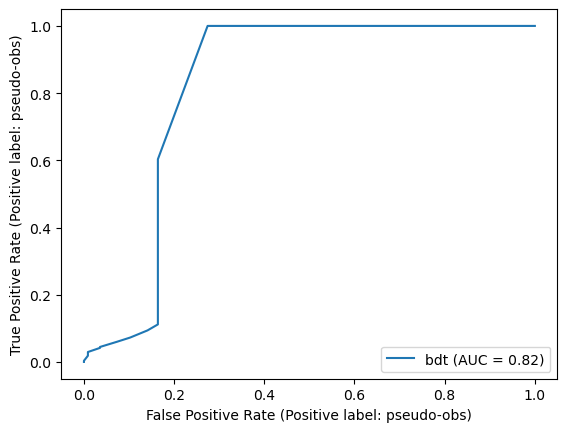

In [15]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name="bdt")

<AxesSubplot: >

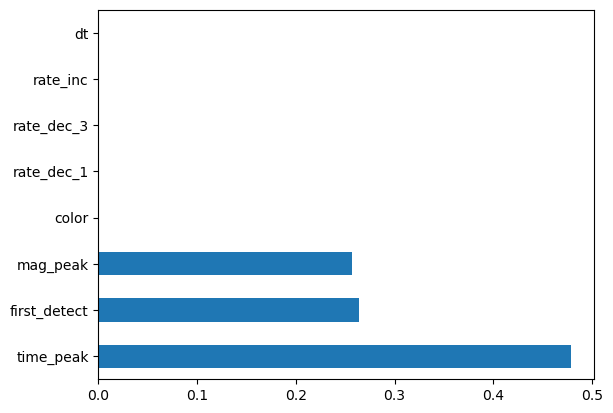

In [16]:
# plot feature importance
feat_importances = pd.Series(clf.feature_importances_, index=X_test.columns)
feat_importances.nlargest(20).plot(kind='barh')